In [2]:
import torch
from dinosaw.helpers import ModelTypes, get_models, get_features, model_names

import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager


SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'

flash attention installed


In [3]:
images: list[Image.Image] = []
path = '../paper_figures/data/cosine_sim/'


# Lazy: every image is landscape, fix a size
long_L = 0
for file_name in ('ducklings_crop.png', 'beehive.jpg', 'nmc_ml50_crop_.png'):
    img = Image.open(f'{path}/{file_name}').convert('RGB')

    shortest = min(img.size)
    short_L = 518
    sf = short_L / shortest

    long_L = 1.5 * short_L

    new_size = (int(long_L), int(short_L))
    img = img.resize(new_size, resample=Image.BILINEAR)

    images.append(img)

In [4]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'alibi_dv2_coco', 'dv3', 'alibi_dv3')
models = get_models(enabled_models, '../../trained_models', device=DEVICE, conf_path='../../dinov3')

In [5]:
features = {name: [] for name in enabled_models}

for image in images:
    for key, model in models.items():
        feats = get_features(model, image, device=DEVICE)
        feats = np.transpose(feats, (1, 2, 0))
        h, w, c = feats.shape

        feats_flat = feats.reshape(-1, c)

        feats_normed = feats_flat  #/ np.linalg.norm(feats_flat, axis=-1, keepdims=True)
        features[key].append(feats_normed.reshape(h, w, c))

In [6]:
def add_inset_zoom(xywh: list[int], fig_xywh: list[float], img_arr: np.ndarray, ax ) -> object:
    x0, y0, w, h = xywh
    H, W, C = img_arr.shape
    inset_data = np.zeros_like(img_arr)
    inset_data[y0:y0+h, x0:x0+w, :] = img_arr[y0:y0+h, x0:x0+w, :]

    axin = ax.inset_axes(
        fig_xywh, xlim=(x0, x0+w), ylim=(y0, y0+h))
    axin.set_xticks([])
    axin.set_yticks([])

    axin.imshow(inset_data) # cmap="binary_r"
    ax.indicate_inset_zoom(axin, edgecolor="red", lw=0.25)
    axin.set_ylim((y0 + h, y0))

    axin.patch.set_edgecolor('red')  
    axin.patch.set_linewidth(2)  

    return axin

def hide_axes(ax: plt.Axes):
    ax.set_xticks([])
    ax.set_yticks([])

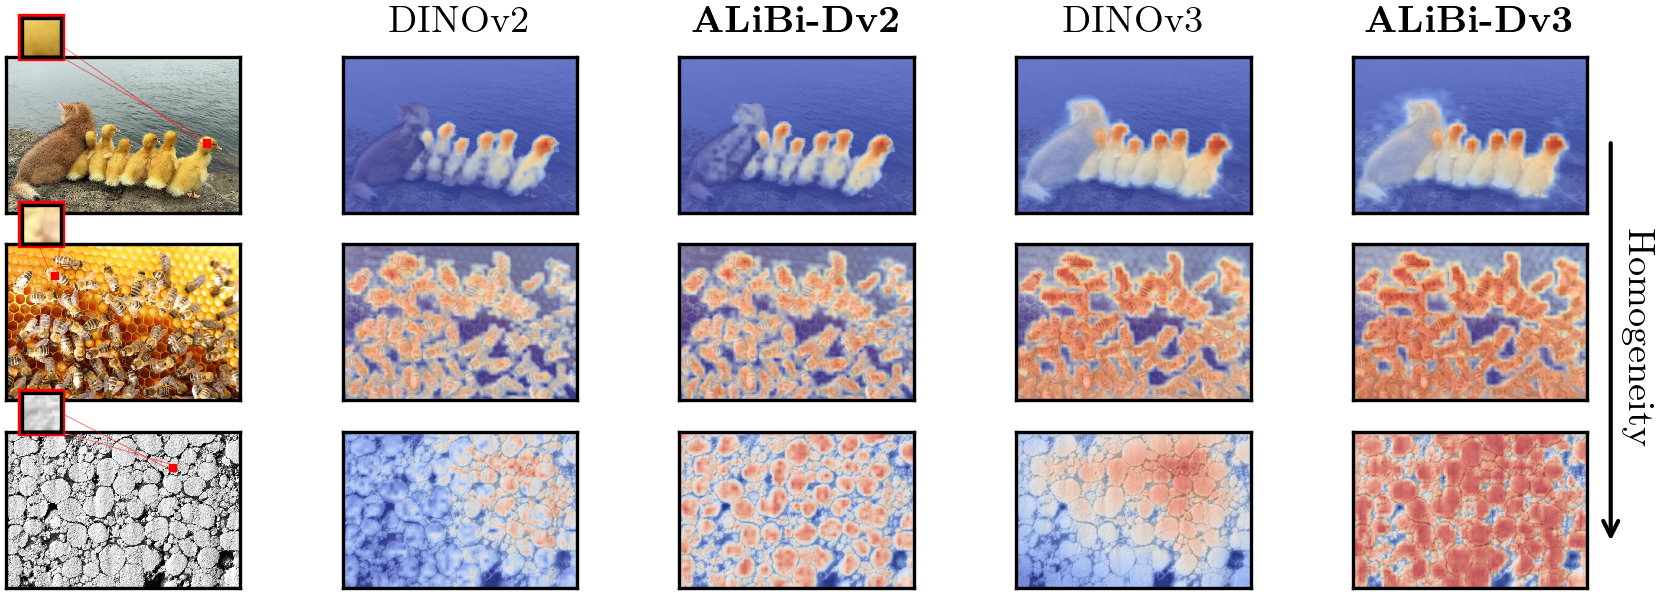

In [ ]:
# %%capture
plt.style.use("thesis.mplstyle")
from matplotlib.patches import Rectangle, Arrow
from numpy.linalg import norm

from skimage.transform import resize


# patch_locs = [(47, 20), (8, 25),  (11, 7),  (39, 8),]
# patch_locs_xy = [(loc[0] * 14, loc[1] * 14) for loc in patch_locs]
patch_locs = [(47, 20),  (11, 7),  (39, 8),]
patch_locs_xy = [(loc[0] * 14, loc[1] * 14) for loc in patch_locs]

W, H = 7, 2.3

S_lookup = {'dv2': 14, 'alibi_dv2_coco': 14, 'dv3': 16, 'alibi_dv3': 16}
name_lookup = {'dv2': 'DINOv2', 'alibi_dv2_coco': 'ALiBi-Dv2', 'dv3': 'DINOv3', 'alibi_dv3': 'ALiBi-Dv3'}

fig, axs = plt.subplots(len(images), 1 + len(models), figsize=(W, H))

i = 0
for image in images:
    j = 1
    loc = patch_locs[i]
    axs[i, 0].imshow(image, interpolation='nearest')

    S = S_lookup[enabled_models[0]]

    add_inset_zoom(
        xywh=[loc[0] * S, loc[1] * S, S, S],
        fig_xywh=[0.05, 1, 0.2, 0.25],
        img_arr=np.array(image),
        ax=axs[i, 0])
    hide_axes(axs[i, 0])


    artist = Rectangle((loc[0] * S, loc[1] * S), S, S, color='red', fill=False, linewidth=1)
    axs[i, 0].add_artist(artist)

    for k, (key, model) in enumerate(models.items()):
        S = S_lookup[key]

        data_loc = (patch_locs_xy[i][0] // S, patch_locs_xy[i][1] // S)

        if i == 0:
            title = model_names[key]
            weight = 500
            title = title.replace("(COCO)", "")
            if 'alibi' in title.lower():
                title = rf"\textbf{{{title}}}"
                weight = 700
            axs[0, j].set_title(f'{title}')

        emb = features[key][i]
        emb = emb.transpose(2, 0, 1)
        ref_emb = emb[:, data_loc[1], data_loc[0]]

        c, h, w = emb.shape

        flat = emb.reshape(emb.shape[0], -1)
        sim = np.dot(ref_emb, flat) / (norm(ref_emb) * norm(flat, axis=0) + 1e-8)
        sim = sim.reshape((h, w))

        sim_map_resized = resize(
        sim,
        (image.height, image.width),
        order=1,  # bilinear
        preserve_range=True,
        anti_aliasing=True
    )

        axs[i, j].imshow(image)
        axs[i, j].imshow(sim_map_resized, cmap='coolwarm', alpha=0.7, interpolation='bilinear', vmin=0.5, vmax=1)
        hide_axes(axs[i, j])

        j += 1

    # for ax in axs[i]:
    #     ax.set_axis_off()
    i += 1


ARROW_X = 1.1
axs[0, -1].annotate('', xy=(ARROW_X, 0.5), xycoords='axes fraction', xytext=(ARROW_X, - len(images) + 0.85), 
            arrowprops=dict(arrowstyle="<-", color='black', linewidth=1))
axs[0, -1].text(ARROW_X + 0.12, -0.8, 'Homogeneity', transform=axs[0, -1].transAxes,
             rotation=270, va='center', ha='center')


# plt.tight_layout()
# plt.savefig('saved/03c.png', dpi=300, bbox_inches='tight')
plt.savefig("out/cosine_sim.pdf", dpi=300, bbox_inches='tight')
# plt.close()